In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Problem 3: The Palmer Archipelago Penguin Data

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/penguins_size.csv'
data = pd.read_csv(url)
data.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
# drop rows with missing values
data.dropna(axis=0, how='any', inplace=True)

In [4]:
data.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [20]:
# feature matrix X
X = data.drop(['species','island'],axis=1)

X[X.sex=='.']


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,44.5,15.7,217.0,4875.0,.


In [22]:
X = X.drop(336)

In [25]:
encoder = {'MALE':0,'FEMALE':1}

X.sex = X.sex.replace(encoder).astype('int32')

In [26]:
X.dtypes

culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                    int32
dtype: object

**Part 1:** Cluster the penguins using k-means.
Ensure that you have selected a good number of clusters (using the "elbow" method or the "silhouette score", for example).

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_list = np.arange(2,15)
scores = []
for k in k_list:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    scores.append(silhouette_score(X,kmeans.labels_))

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warning

Text(0, 0.5, 'silhouette score')

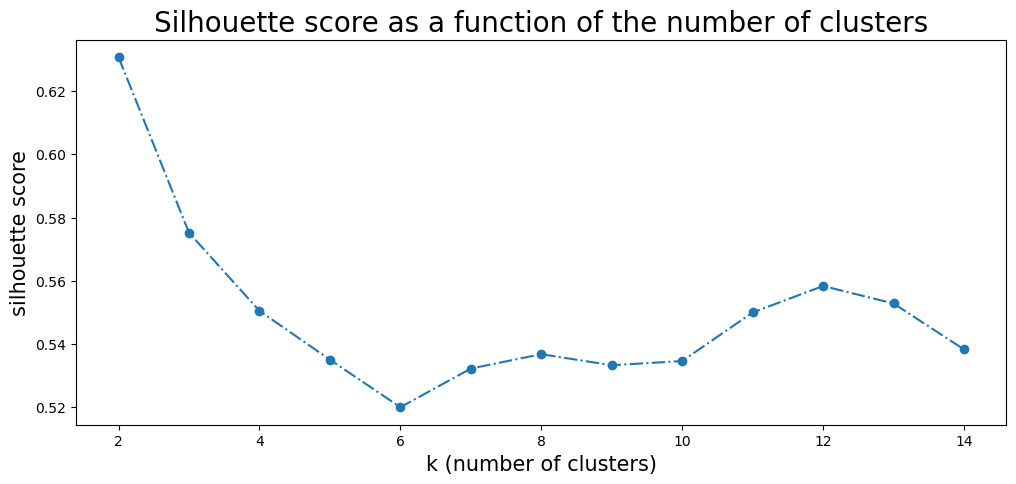

In [28]:
plt.figure(figsize=(12,5))
plt.plot(k_list,scores,'o-.')
plt.title('Silhouette score as a function of the number of clusters',fontsize=20)
plt.xlabel('k (number of clusters)', fontsize=15)
plt.ylabel('silhouette score', fontsize=15)

In [29]:
# six clusters looks like an elbow here

kmeans = KMeans(n_clusters=6)
kmeans.fit(X)

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=6)

**Part 2:** Analyze the obtained clusters

In [31]:
labels = kmeans.labels_

In [32]:
X.species[labels==0]

AttributeError: 'DataFrame' object has no attribute 'species'

In [33]:
data = data.drop(336)

len(data)==len(X)

True

In [34]:
data.species[labels==0].value_counts()

Adelie       39
Chinstrap    18
Gentoo        8
Name: species, dtype: int64

In [35]:
data.species[labels==1].value_counts()

Gentoo    40
Name: species, dtype: int64

In [36]:
data.species[labels==2].value_counts()

Adelie       37
Chinstrap    11
Name: species, dtype: int64

In [37]:
data.species[labels==3].value_counts()

Gentoo       37
Adelie       14
Chinstrap     5
Name: species, dtype: int64

In [38]:
data.species[labels==4].value_counts()

Gentoo    34
Name: species, dtype: int64

In [39]:
data.species[labels==5].value_counts()

Adelie       56
Chinstrap    34
Name: species, dtype: int64

In [42]:
data[['sex','species']][labels==5].value_counts()

sex     species  
FEMALE  Adelie       36
        Chinstrap    21
MALE    Adelie       20
        Chinstrap    13
dtype: int64

Our clusters seems to be mixing Adelie and Chinstrap penguins. Gentoo seem to be more distinguishable by the method.